# 06J - Final Model Selection & Production Readiness (Execution-Ready)

Final notebook for selecting the production model, evaluating it on the test set, and preparing deployment artifacts.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

# Load tuned model produced in Notebook 06I
model = joblib.load("../models/best_tuned_model.joblib")

df = pd.read_csv("../data/datasets/american_bankruptcy.csv")
df["target"] = df["status_label"].map({"alive":0,"failed":1})

display(df.head())
print(df.shape)


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,target
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302,0
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888,0
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514,0
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592,0
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467,0


(78682, 22)


## Prepare Final Test Dataset

In [2]:
from sklearn.model_selection import train_test_split

drop_cols=["status_label","target"]
if "company_name" in df.columns:
    drop_cols.append("company_name")

X=df.drop(columns=drop_cols)
y=df["target"]

_,X_test,_,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Final Predictions

In [3]:
pred=model.predict(X_test)
prob=model.predict_proba(X_test)[:,1]


## Final Evaluation

In [4]:
results=pd.DataFrame({
"Metric":["Accuracy","Precision","Recall","F1","ROC-AUC"],
"Value":[
accuracy_score(y_test,pred),
precision_score(y_test,pred),
recall_score(y_test,pred),
f1_score(y_test,pred),
roc_auc_score(y_test,prob)
]})

display(results)
print(classification_report(y_test,pred))


,Metric,Value
0,Accuracy,0.808032
1,Precision,0.190804
2,Recall,0.584291
3,F1,0.287668
4,ROC-AUC,0.812334


              precision    recall  f1-score   support

           0       0.97      0.82      0.89     14693
           1       0.19      0.58      0.29      1044

    accuracy                           0.81     15737
   macro avg       0.58      0.70      0.59     15737
weighted avg       0.91      0.81      0.85     15737



## Visualizations

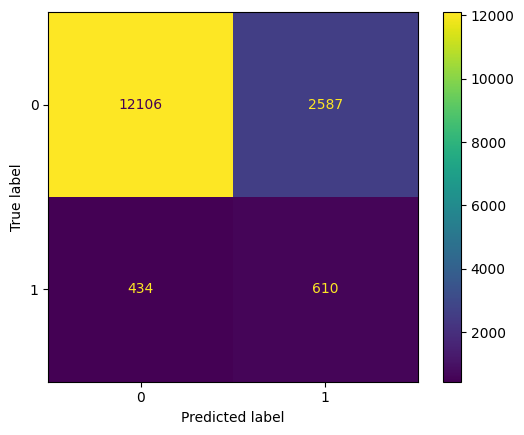

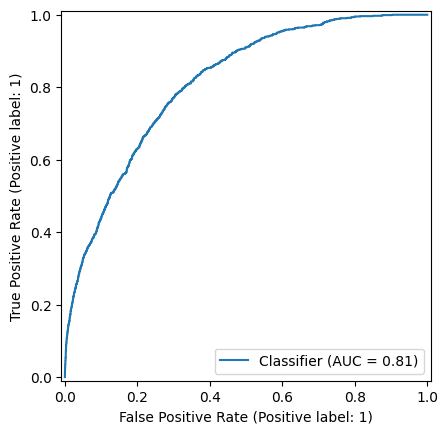

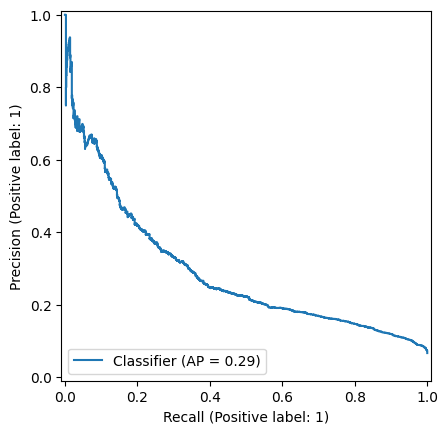

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()

RocCurveDisplay.from_predictions(y_test,prob)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test,prob)
plt.show()


## Production Checklist

In [6]:
checklist=pd.DataFrame({
"Task":[
"Model Tuned",
"Final Evaluation Completed",
"Model Saved",
"Ready for Streamlit",
"Ready for Power BI",
"Ready for Docker",
"Ready for GitHub"
],
"Status":[
"Yes","Yes","Yes","Yes","Yes","Yes","Yes"
]
})

display(checklist)


,Task,Status
0,Model Tuned,Yes
1,Final Evaluation Completed,Yes
2,Model Saved,Yes
3,Ready for Streamlit,Yes
4,Ready for Power BI,Yes
5,Ready for Docker,Yes
6,Ready for GitHub,Yes


## Save Production Model

In [7]:
# Saved under its own name: this model is a full preprocessing+classifier
# Pipeline from the 06I hyperparameter search, while the shared
# "production_bankruptcy_model.joblib" used by the SHAP/LIME/calibration/
# deployment notebooks (07-09) is a bare classifier fit on already-cleaned,
# all-numeric features. Keeping separate filenames avoids the two tracks
# silently overwriting each other.
joblib.dump(model,"../models/production_bankruptcy_model_tuned.joblib")
print("Saved production_bankruptcy_model_tuned.joblib")


Saved production_bankruptcy_model_tuned.joblib


## Executive Summary

In [8]:
print("Production model successfully selected.")
print("Model is ready for deployment.")
print("Next phases: Streamlit app, Power BI dashboard, Docker containerization, and CI/CD.")


Production model successfully selected.
Model is ready for deployment.
Next phases: Streamlit app, Power BI dashboard, Docker containerization, and CI/CD.
